In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *


In [17]:
pnas_normal_readcounts = pd.read_csv('data/reads/pnas_normal_tpm.txt', sep='\t')
pnas_readcounts_96 = pd.read_csv('data/reads/pnas_tpm_96_nodup.txt', sep='\t', header=None)

pnas_readcounts_96 = pnas_readcounts_96.set_index(pnas_readcounts_96.columns[0])

print(pnas_normal_readcounts.shape)
print(pnas_readcounts_96.shape)

n_normal = pnas_normal_readcounts.shape[1]
n_cancer = pnas_readcounts_96.shape[1]

data = pd.concat([pnas_normal_readcounts, pnas_readcounts_96], axis=1).T

print(len(data), n_normal + n_cancer)

data["cancer_status"] = [0] * n_normal + [1] * n_cancer

print(data)
print(data.shape)

(60675, 32)
(60675, 96)
128 128
    ENSG00000000003  ENSG00000000005  ENSG00000000419  ENSG00000000457  \
N1        26.432148        24.817762        66.208114         8.127159   
N2        17.260895         5.402219         0.000000         6.318156   
N3         0.000000         7.557640        10.081027        15.910242   
N4        69.795165         0.000000         0.000000        15.328639   
N5        19.331552         0.000000        18.158365        19.105460   
..              ...              ...              ...              ...   
92         0.000000         0.000000       179.178412        83.788404   
93        38.189128         5.976111        15.942897        18.172309   
94        15.608352         6.280734         0.000000         2.938248   
95        51.519267       241.863225         0.000000        14.547636   
96        30.805593         0.000000         0.000000        10.148436   

    ENSG00000000460  ENSG00000000938  ENSG00000000971  ENSG00000001036  \
N1   

In [25]:
threshold = 0.1
min_sample_fraction = 0.20

min_samples = int(len(data) * min_sample_fraction)

gene_mask = (data > threshold).sum(axis=0) >= min_samples

filtered_data = data.loc[:, gene_mask]

print(filtered_data.shape)

(128, 43028)


# Whole Dataset

In [26]:
scaler = MinMaxScaler()
X = filtered_data.drop(columns=["cancer_status"])
y = filtered_data["cancer_status"]
X_scaled = scaler.fit_transform(X)

## Logistic Regression

LR Model Cross-validation average score: 0.8828571428571429
Accuracy: 0.8461538461538461
Precision: 0.8181818181818182
Recall: 1.0
F1 Score: 0.9
ROC-AUC Score: 0.9652777777777778
Confusion Matrix:
[[ 4  4]
 [ 0 18]]


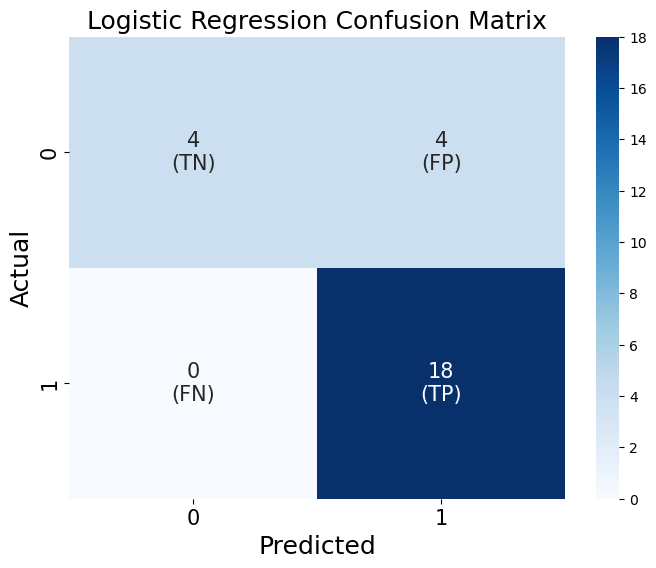

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

LR_Model = LogisticRegression()

LR_cross_scores = cross_val_score(LR_Model, X_train, y_train, cv=5)
print(f'LR Model Cross-validation average score: {LR_cross_scores.mean()}')

# Train the model
LR_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = LR_Model.predict(X_test)
y_pred_proba = LR_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
LR_accuracy = accuracy_score(y_test, y_pred)
LR_precision = precision_score(y_test, y_pred)
LR_recall = recall_score(y_test, y_pred)
LR_f1 = f1_score(y_test, y_pred)
LR_roc_auc = roc_auc_score(y_test, y_pred_proba)
LR_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {LR_accuracy}')
print(f'Precision: {LR_precision}')
print(f'Recall: {LR_recall}')
print(f'F1 Score: {LR_f1}')
print(f'ROC-AUC Score: {LR_roc_auc}')
print(f'Confusion Matrix:\n{LR_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{LR_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(LR_conf_matrix.shape[1])] 
                              for i in range(LR_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(LR_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Logistic Regression Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Random Forest

RF Model Cross-validation average score: 0.8933333333333332
Accuracy: 0.8076923076923077
Precision: 0.782608695652174
Recall: 1.0
F1 Score: 0.878048780487805
ROC-AUC Score: 0.9930555555555556
Confusion Matrix:
[[ 3  5]
 [ 0 18]]


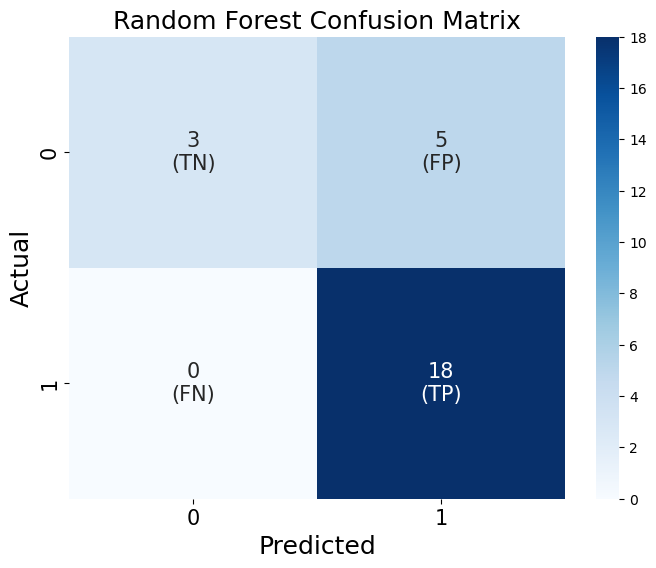

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

RF_Model = RandomForestClassifier()

RF_cross_scores = cross_val_score(RF_Model, X_train, y_train, cv=5)
print(f'RF Model Cross-validation average score: {RF_cross_scores.mean()}')

# Train the model
RF_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = RF_Model.predict(X_test)
y_pred_proba = RF_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
RF_accuracy = accuracy_score(y_test, y_pred)
RF_precision = precision_score(y_test, y_pred)
RF_recall = recall_score(y_test, y_pred)
RF_f1 = f1_score(y_test, y_pred)
RF_roc_auc = roc_auc_score(y_test, y_pred_proba)
RF_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {RF_accuracy}')
print(f'Precision: {RF_precision}')
print(f'Recall: {RF_recall}')
print(f'F1 Score: {RF_f1}')
print(f'ROC-AUC Score: {RF_roc_auc}')
print(f'Confusion Matrix:\n{RF_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{RF_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(RF_conf_matrix.shape[1])] 
                              for i in range(RF_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(RF_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Random Forest Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Naive Bayes

NB Model Cross-validation average score: 0.7647619047619048
Accuracy: 0.6923076923076923
Precision: 0.6923076923076923
Recall: 1.0
F1 Score: 0.8181818181818181
ROC-AUC Score: 0.5
Confusion Matrix:
[[ 0  8]
 [ 0 18]]


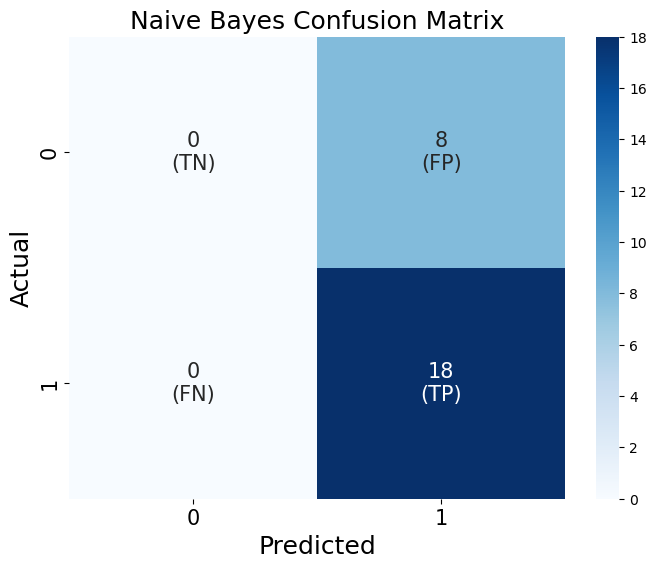

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

NB_Model = GaussianNB()

NB_cross_scores = cross_val_score(NB_Model, X_train, y_train, cv=5)
print(f'NB Model Cross-validation average score: {NB_cross_scores.mean()}')

# Train the model
NB_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = NB_Model.predict(X_test)
y_pred_proba = NB_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
NB_accuracy = accuracy_score(y_test, y_pred)
NB_precision = precision_score(y_test, y_pred)
NB_recall = recall_score(y_test, y_pred)
NB_f1 = f1_score(y_test, y_pred)
NB_roc_auc = roc_auc_score(y_test, y_pred_proba)
NB_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {NB_accuracy}')
print(f'Precision: {NB_precision}')
print(f'Recall: {NB_recall}')
print(f'F1 Score: {NB_f1}')
print(f'ROC-AUC Score: {NB_roc_auc}')
print(f'Confusion Matrix:\n{NB_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{NB_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(NB_conf_matrix.shape[1])] 
                              for i in range(NB_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(NB_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Naive Bayes Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Support Vector Machine

SVM Model Cross-validation average score: 0.7654545454545455
Accuracy: 0.6923076923076923
Precision: 0.6923076923076923
Recall: 1.0
F1 Score: 0.8181818181818181
ROC-AUC Score: 0.9583333333333333
Confusion Matrix:
[[ 0  8]
 [ 0 18]]


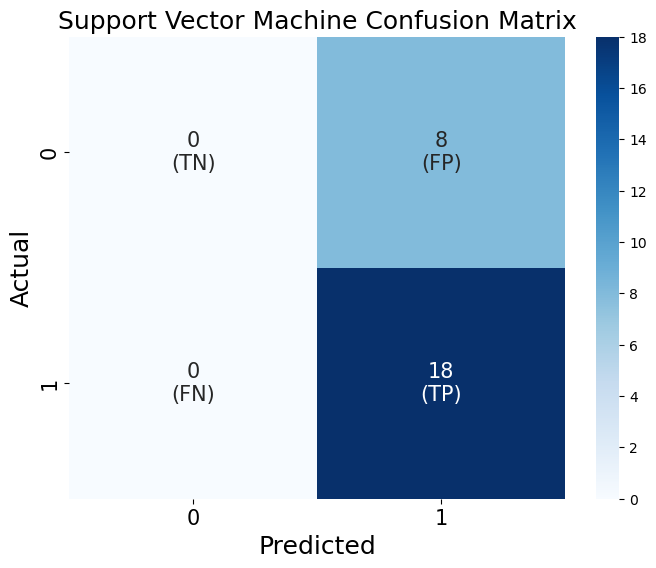

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

SVM_Model = SVC(probability=True)

SVM_cross_scores = cross_val_score(SVM_Model, X_train, y_train, cv=10)
print(f'SVM Model Cross-validation average score: {SVM_cross_scores.mean()}')

# Train the model
SVM_Model.fit(X_train, y_train)

# Predict on the test set
y_pred = SVM_Model.predict(X_test)
y_pred_proba = SVM_Model.predict_proba(X_test)[:, 1]

# Evaluation metrics
SVM_accuracy = accuracy_score(y_test, y_pred)
SVM_precision = precision_score(y_test, y_pred)
SVM_recall = recall_score(y_test, y_pred)
SVM_f1 = f1_score(y_test, y_pred)
SVM_roc_auc = roc_auc_score(y_test, y_pred_proba)
SVM_conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {SVM_accuracy}')
print(f'Precision: {SVM_precision}')
print(f'Recall: {SVM_recall}')
print(f'F1 Score: {SVM_f1}')
print(f'ROC-AUC Score: {SVM_roc_auc}')
print(f'Confusion Matrix:\n{SVM_conf_matrix}')

labels = np.array([["TN", "FP"],
                   ["FN", "TP"]])
annot_matrix = np.array([[f"{SVM_conf_matrix[i, j]}\n({labels[i, j]})" 
                              for j in range(SVM_conf_matrix.shape[1])] 
                              for i in range(SVM_conf_matrix.shape[0])])

value, counts = np.unique(y_test, return_counts=True)
max_counts = max(counts)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(SVM_conf_matrix, annot=annot_matrix, cmap="Blues", fmt="", annot_kws={"size": 15}, vmin=0, vmax=max_counts)
plt.title("Support Vector Machine Confusion Matrix", fontsize=18)
plt.ylabel("Actual", fontsize=18)
plt.xlabel("Predicted", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Hyperparameter Tuning

In [23]:
print('Parameters currently in use:\n')
pprint(.get_params())

SyntaxError: invalid syntax (3166829110.py, line 2)

# Breast Cancer Gene Subset